AVERAGED RESULTS ACROSS SESSIONS AND MICE

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import linregress

sns.set_theme(context='talk', style='ticks', palette='colorblind')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.titlesize'] = 'medium'
plt.rcParams['axes.titlelocation'] = 'left'

SCRATCH_DIR = '/scratch/rt_analysis'
DATA_DIR = os.path.join(SCRATCH_DIR, 'data')
FIGURE_DIR = os.path.join(SCRATCH_DIR, 'figures')
os.makedirs(FIGURE_DIR, exist_ok=True)

CONTEXT_ROWS = [('aud', 'Auditory'), ('vis', 'Visual')]
STREAK_COLUMNS = [('consecutive_rewarded', '# previous consecutive rewarded trials'), ('consecutive_unrewarded', '# previous consecutive unrewarded trials')]
OUTCOME_COLORS = {'hit': 'tab:blue', 'false alarm': 'tab:red'}
RT_OUTCOMES = ['hit', 'false alarm']
MAX_STREAK_LEVEL = {'consecutive_rewarded': 4, 'consecutive_unrewarded': 6}
MIN_TRIALS_PER_LEVEL = 2
MIN_SESSIONS_FOR_FIT = 2

# Load each session data
trial_files = sorted(glob.glob(os.path.join(DATA_DIR, '*__trials.csv')))
assert trial_files, 'no trials.csv files found in %s' % DATA_DIR
all_trials = pd.concat([pd.read_csv(f) for f in trial_files], ignore_index=True)
print('%d sessions, %d trials total' % (all_trials.session_id.nunique(), len(all_trials)))

analysis_trials = all_trials[all_trials.in_rt_analysis & all_trials.outcome.isin(RT_OUTCOMES) & all_trials.reaction_time.notna()]

# Median per streak and session
level_rows = []
for streak_column, _ in STREAK_COLUMNS:
    capped = analysis_trials[analysis_trials[streak_column] <= MAX_STREAK_LEVEL[streak_column]]
    grouped = capped.groupby(['session_id', 'rewarded_modality', 'outcome', streak_column]).reaction_time
    summary = grouped.agg(['median', 'size']).reset_index()
    summary.columns = ['session_id', 'context', 'outcome', 'streak_level', 'rt_median', 'n_trials']
    summary['streak'] = streak_column
    level_rows.append(summary)

level_medians = pd.concat(level_rows, ignore_index=True)
level_medians = level_medians[level_medians.n_trials >= MIN_TRIALS_PER_LEVEL]

12 sessions, 6247 trials total


Auditory, # previous consecutive rewarded trials, hit: slope -14.2 ms/trial (SE 12.7), p = 0.27, 60 session-levels from 12 sessions
Auditory, # previous consecutive rewarded trials, false alarm: slope -33.2 ms/trial (SE 30.9), p = 0.29, 26 session-levels from 12 sessions
Auditory, # previous consecutive unrewarded trials, hit: slope +7.7 ms/trial (SE 7.3), p = 0.29, 82 session-levels from 12 sessions
Auditory, # previous consecutive unrewarded trials, false alarm: slope +18.7 ms/trial (SE 8.8), p = 0.038, 63 session-levels from 12 sessions
Visual, # previous consecutive rewarded trials, hit: slope -27.3 ms/trial (SE 6.7), p = 0.00013, 60 session-levels from 12 sessions
Visual, # previous consecutive rewarded trials, false alarm: slope -16.5 ms/trial (SE 44.6), p = 0.72, 22 session-levels from 12 sessions
Visual, # previous consecutive unrewarded trials, hit: slope +12.4 ms/trial (SE 5.1), p = 0.018, 82 session-levels from 12 sessions
Visual, # previous consecutive unrewarded trials, fa

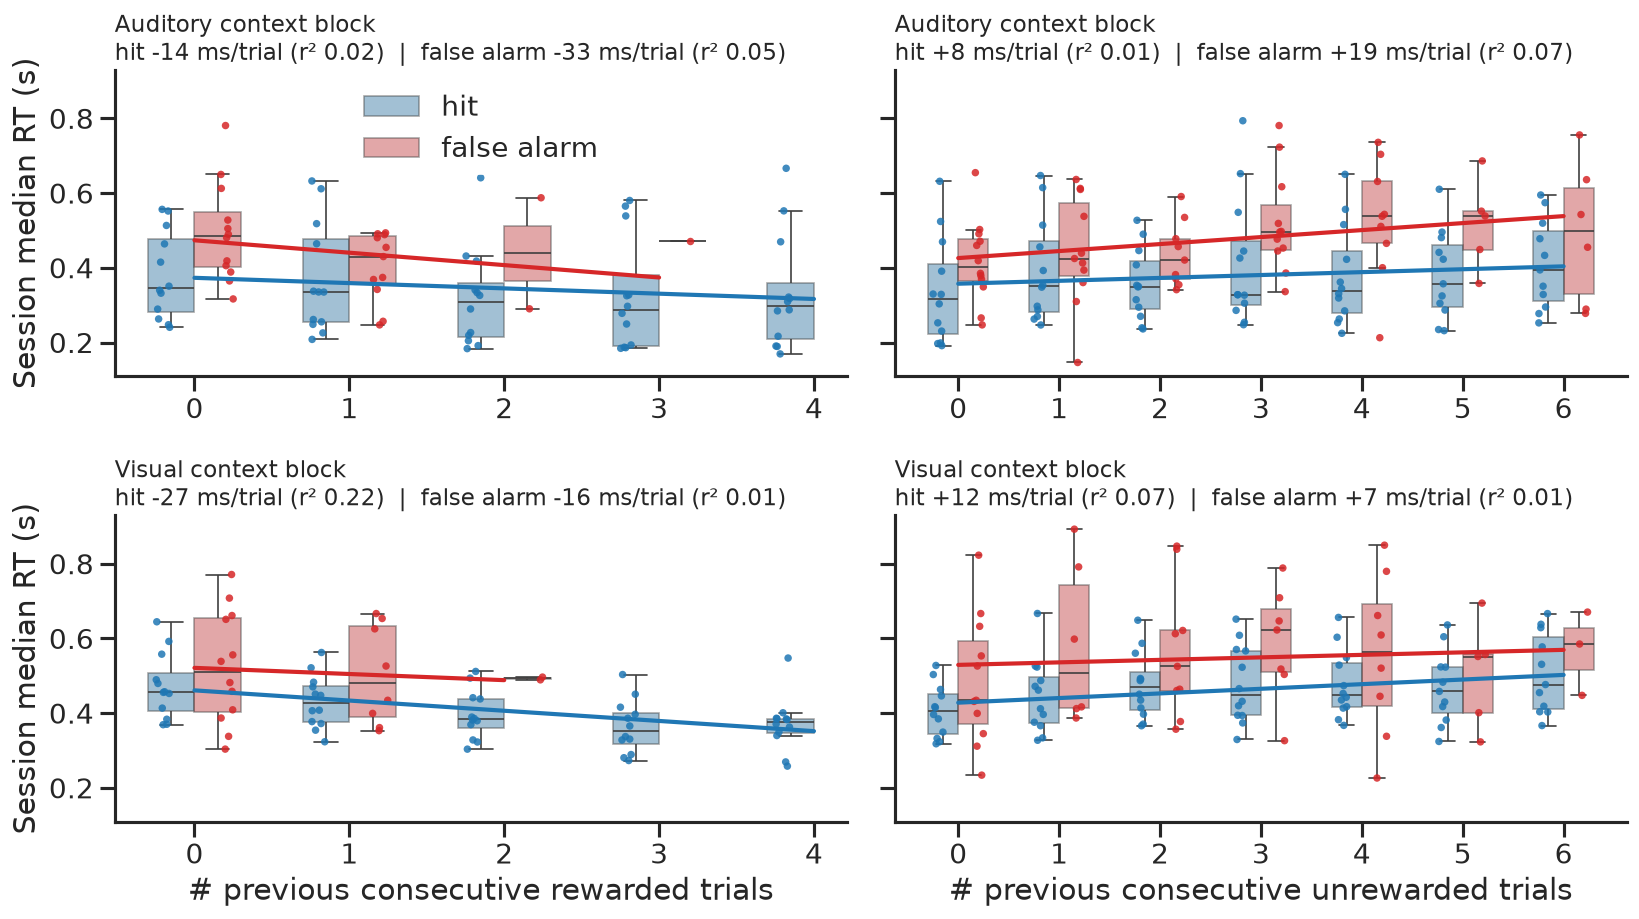

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
for row_index, (context_value, context_label) in enumerate(CONTEXT_ROWS):
    for col_index, (streak_column, column_label) in enumerate(STREAK_COLUMNS):
        ax = axes[row_index, col_index]
        panel_data = level_medians[(level_medians.context == context_value) & (level_medians.streak == streak_column)]
        if not len(panel_data):
            ax.set_title('%s context block: no data' % context_label, fontsize=12)
            sns.despine(ax=ax)
            continue
        level_order = sorted(panel_data.streak_level.unique())

        sns.boxplot(data=panel_data, x='streak_level', y='rt_median',
                    hue='outcome', hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                    order=level_order, width=0.6, showfliers=False, linewidth=1,
                    boxprops={'alpha': 0.45},
                    legend=(row_index == 0 and col_index == 0), ax=ax)
        sns.stripplot(data=panel_data, x='streak_level', y='rt_median',
                      hue='outcome', hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                      order=level_order, dodge=True, size=4.5, alpha=0.85,
                      linewidth=0, legend=False, ax=ax)

        position_by_level = {level: position for position, level in enumerate(level_order)}
        title_parts = []
        for outcome_label in RT_OUTCOMES:
            outcome_data = panel_data[panel_data.outcome == outcome_label]
            x = outcome_data.streak_level.map(position_by_level).values.astype(float)
            y = outcome_data.rt_median.values.astype(float)
            if len(x) < MIN_SESSIONS_FOR_FIT or len(np.unique(x)) < 2:
                title_parts.append('%s: not fitted' % outcome_label)
                continue
            result = linregress(x, y)
            x_line = np.array([x.min(), x.max()])
            ax.plot(x_line, result.intercept + result.slope * x_line, color=OUTCOME_COLORS[outcome_label], lw=2.5, zorder=5)
            title_parts.append('%s %+.0f ms/trial (r\u00b2 %.2f)' % (outcome_label, result.slope * 1e3, result.rvalue ** 2))
            print('%s, %s, %s: slope %+.1f ms/trial (SE %.1f), p = %.2g, ' '%d session-levels from %d sessions'
                     % (context_label, column_label, outcome_label,
                     result.slope * 1e3, result.stderr * 1e3, result.pvalue,
                     len(x), outcome_data.session_id.nunique()))

        ax.set_title('%s context block\n%s' % (context_label, '  |  '.join(title_parts)), fontsize=14)
        ax.set_xlabel(column_label if row_index == 1 else '')
        ax.set_ylabel('Session median RT (s)' if col_index == 0 else '')
        sns.despine(ax=ax)

legend = axes[0, 0].get_legend()
if legend is not None:
    legend.set_title('')
    legend.prop.set_size(9)
    legend.get_frame().set_linewidth(0)


fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, 'across_sessions__rt_vs_streak.png'), dpi=300, bbox_inches='tight')
plt.show()

In [3]:
CONTEXT_LABELS = {'aud': 'Auditory', 'vis': 'Visual'}
CONTEXT_ORDER = ['aud', 'vis']
CONTEXT_PALETTE = {'aud': 'tab:purple', 'vis': 'tab:orange'}

session_slope_rows = []
for session_name, session_trials in analysis_trials.groupby('session_id'):
    for context_value in CONTEXT_ORDER:
        context_trials = session_trials[session_trials.rewarded_modality == context_value]
        for streak_column, streak_label in STREAK_COLUMNS:
            capped = context_trials[context_trials[streak_column] <= MAX_STREAK_LEVEL[streak_column]]
            for outcome_label in RT_OUTCOMES:
                outcome_data = capped[capped.outcome == outcome_label]
                x = outcome_data[streak_column].values.astype(float)
                y = outcome_data.reaction_time.values.astype(float)
                if len(np.unique(x)) < 2:
                    continue
                result = linregress(x, y)
                session_slope_rows.append({
                    'session_id': session_name,
                    'context': context_value,
                    'streak': streak_column,
                    'streak_label': streak_label,
                    'outcome': outcome_label,
                    'slope_ms': result.slope * 1e3,
                    'se_ms': result.stderr * 1e3,
                    'p': result.pvalue,
                    'n': len(x)})

session_slopes = pd.DataFrame(session_slope_rows)

excluded 6 of 96 fits with |slope| > 100 ms/trial


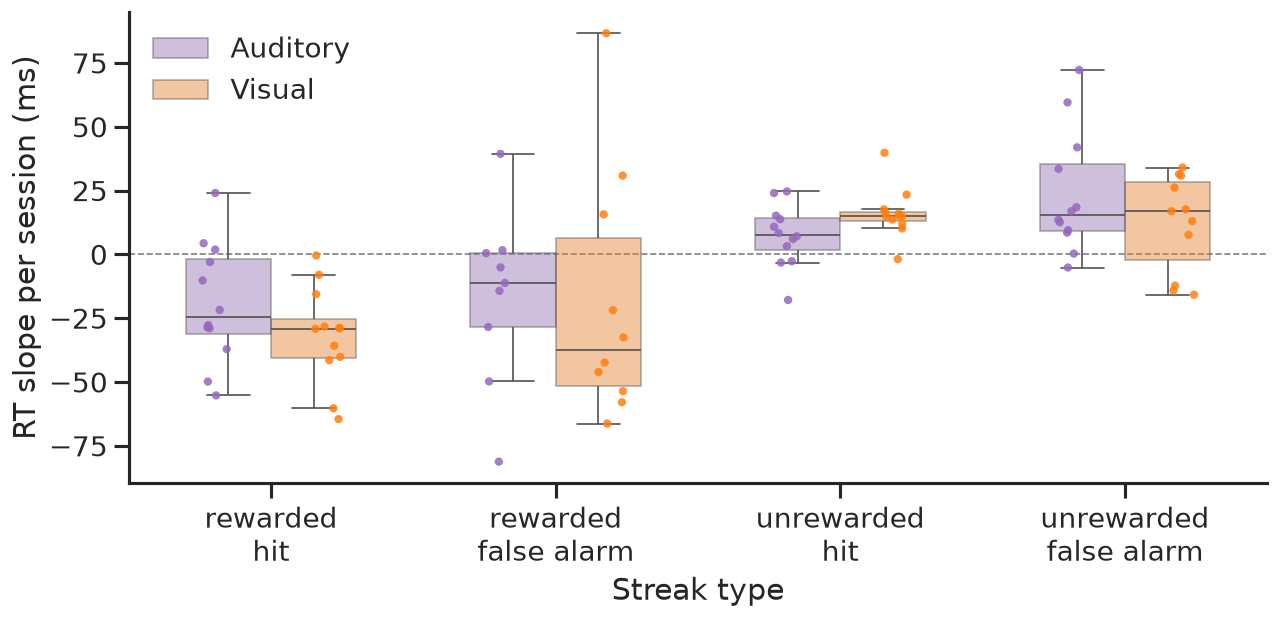

In [4]:
MAX_ABS_SLOPE_MS = 100     # drop fits with |slope| above this, in ms per streak trial

n_before = len(session_slopes)
plot_slopes = session_slopes[session_slopes.slope_ms.abs() <= MAX_ABS_SLOPE_MS]
print('excluded %d of %d fits with |slope| > %d ms/trial' % (n_before - len(plot_slopes), n_before, MAX_ABS_SLOPE_MS))
plot_slopes = plot_slopes.copy()
plot_slopes['group'] = plot_slopes.apply(lambda r: '%s\n%s' % ('unrewarded' if 'unrewarded' in r.streak else 'rewarded', r.outcome), axis=1)
group_order = ['rewarded\nhit', 'rewarded\nfalse alarm', 'unrewarded\nhit', 'unrewarded\nfalse alarm']
group_order = [g for g in group_order if g in set(plot_slopes.group)]

fig, ax = plt.subplots(figsize=(11, 5.5))

sns.boxplot(data=plot_slopes, x='group', y='slope_ms', hue='context',
            hue_order=CONTEXT_ORDER, palette=CONTEXT_PALETTE, order=group_order,
            width=0.6, showfliers=False, linewidth=1,
            boxprops={'alpha': 0.45}, ax=ax)
sns.stripplot(data=plot_slopes, x='group', y='slope_ms', hue='context',
              hue_order=CONTEXT_ORDER, palette=CONTEXT_PALETTE, order=group_order,
              dodge=True, size=5, alpha=0.85, linewidth=0, legend=False, ax=ax)

legend = ax.get_legend()
if legend is not None:
    legend.set_title('')
    for text, context_value in zip(legend.get_texts(), CONTEXT_ORDER):
        text.set_text(CONTEXT_LABELS[context_value])
    legend.prop.set_size(9)
    legend.get_frame().set_linewidth(0)

ax.axhline(0, color='0.5', lw=1, ls='--', zorder=0)
ax.set_xlabel('Streak type')
ax.set_ylabel('RT slope per session (ms)')
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, 'across_sessions__per_session_slopes.png'), dpi=300, bbox_inches='tight')
plt.show()